In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
np.random.seed(42)

print("Setup complete")

Setup complete


In [129]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")

Saving summer_project_data_set (1).csv to summer_project_data_set (1) (4).csv
   Employee ID            Name  Gender Department             Job Role  \
0       376063  Manikya Badami    Male      Sales      Sales Executive   
1       810690      Zara Mahal  Female  Marketing  Marketing Executive   
2       520956       Sana Gera    Male    Finance           Accountant   
3       202996     Zoya Wadhwa    Male  Marketing   Content Strategist   
4       383410    Baiju Doctor    Male      Sales      Sales Executive   

   Performance Score  KPI Score  Attendance (%)  Peer Rating  \
0                 61      91.03           94.40          4.5   
1                 91      83.36           78.45          4.7   
2                100      65.39           99.50          4.4   
3                100      82.90           79.83          4.3   
4                 80      90.90           89.92          3.7   

   Task Completion (%)  Work Hours Logged  Manager Feedback  Training Hours  \
0            

In [130]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (5000, 14)

Data types:
 Employee ID                int64
Name                      object
Gender                    object
Department                object
Job Role                  object
Performance Score          int64
KPI Score                float64
Attendance (%)           float64
Peer Rating              float64
Task Completion (%)      float64
Work Hours Logged          int64
Manager Feedback         float64
Training Hours             int64
Promotion Eligibility     object
dtype: object

Missing values:
 Employee ID              0
Name                     0
Gender                   0
Department               0
Job Role                 0
Performance Score        0
KPI Score                0
Attendance (%)           0
Peer Rating              0
Task Completion (%)      0
Work Hours Logged        0
Manager Feedback         0
Training Hours           0
Promotion Eligibility    0
dtype: int64

Duplicate rows: 0


Promotion Eligibility
No     4305
Yes     695
Name: count, dtype: int64

Percentage:
 Promotion Eligibility
No     86.1
Yes    13.9
Name: proportion, dtype: float64


/tmp/ipykernel_13697/2389832762.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Promotion Eligibility', data=df, palette='Set2')


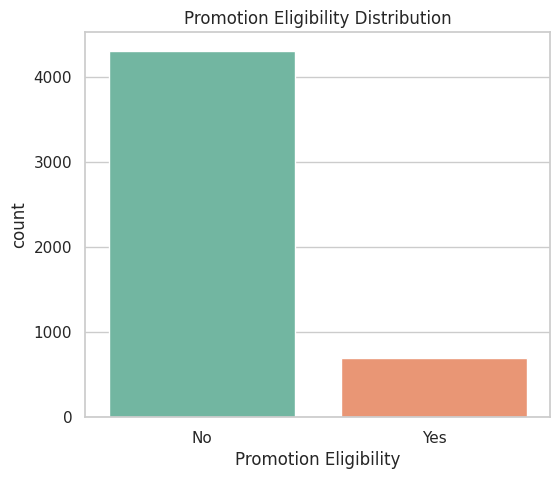

In [131]:
print(df['Promotion Eligibility'].value_counts())
print("\nPercentage:\n", df['Promotion Eligibility'].value_counts(normalize=True).round(3) * 100)

plt.figure(figsize=(6, 5))
sns.countplot(x='Promotion Eligibility', data=df, palette='Set2')
plt.title('Promotion Eligibility Distribution')
plt.show()

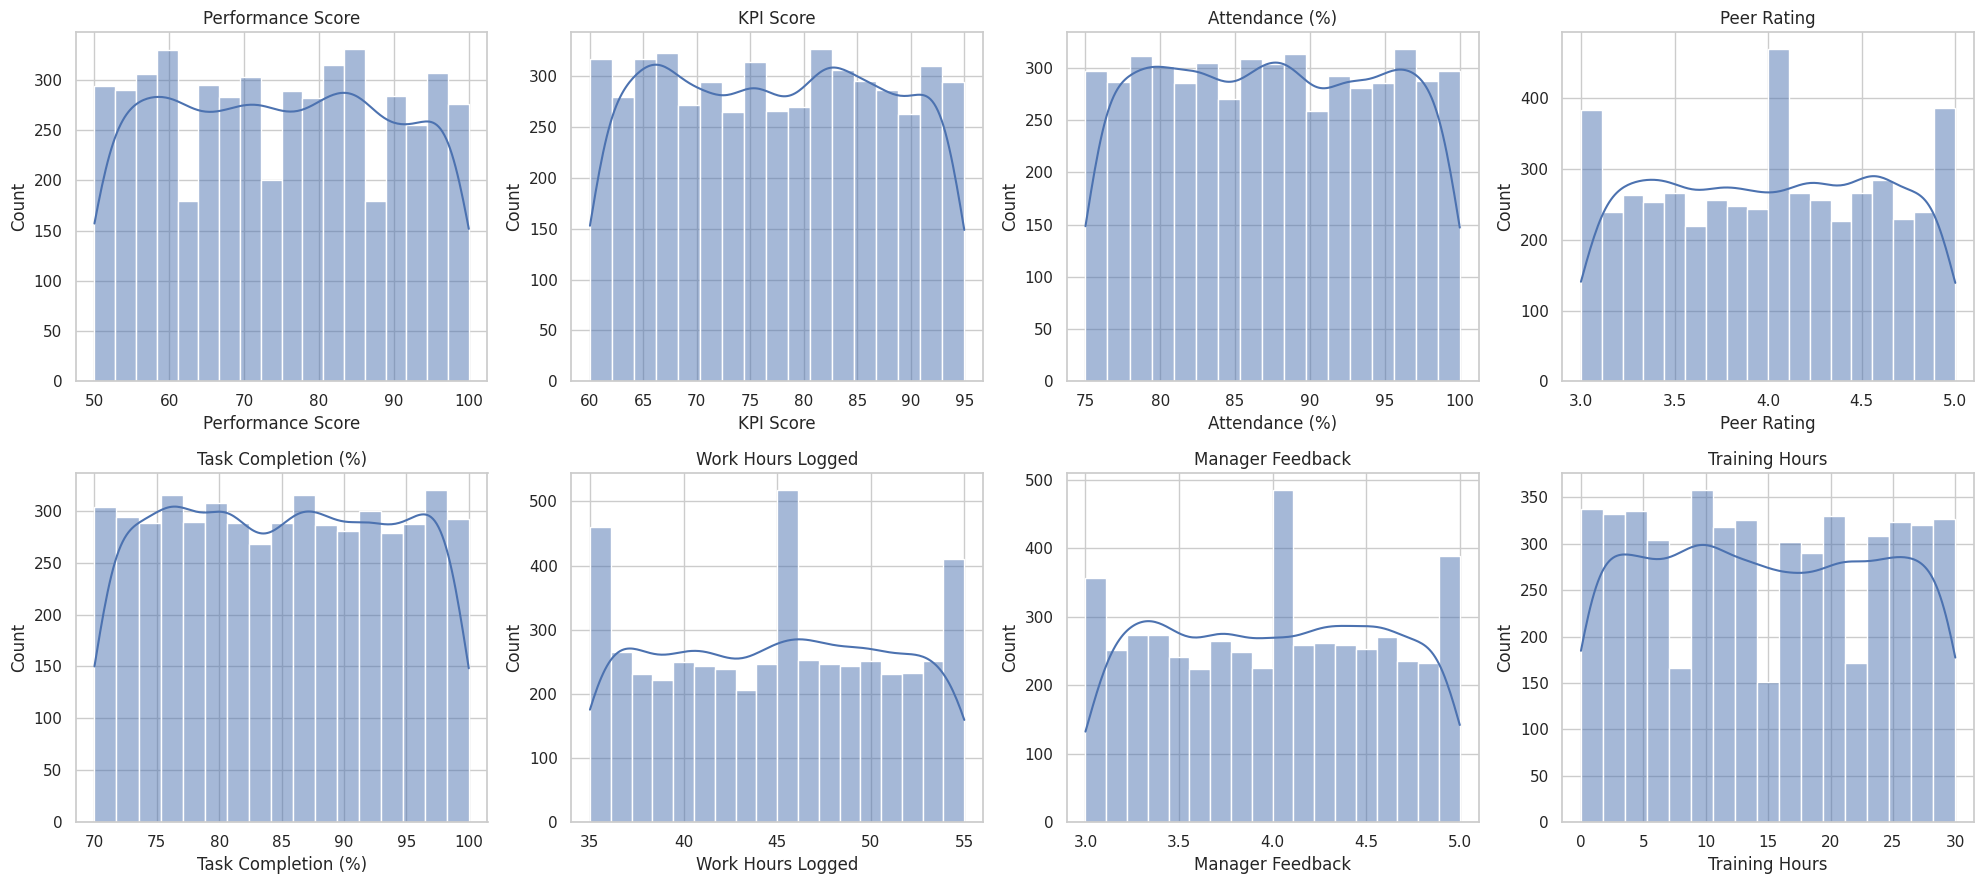

In [132]:
numeric_cols = ['Performance Score', 'KPI Score', 'Attendance (%)', 'Peer Rating',
                 'Task Completion (%)', 'Work Hours Logged', 'Manager Feedback', 'Training Hours']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

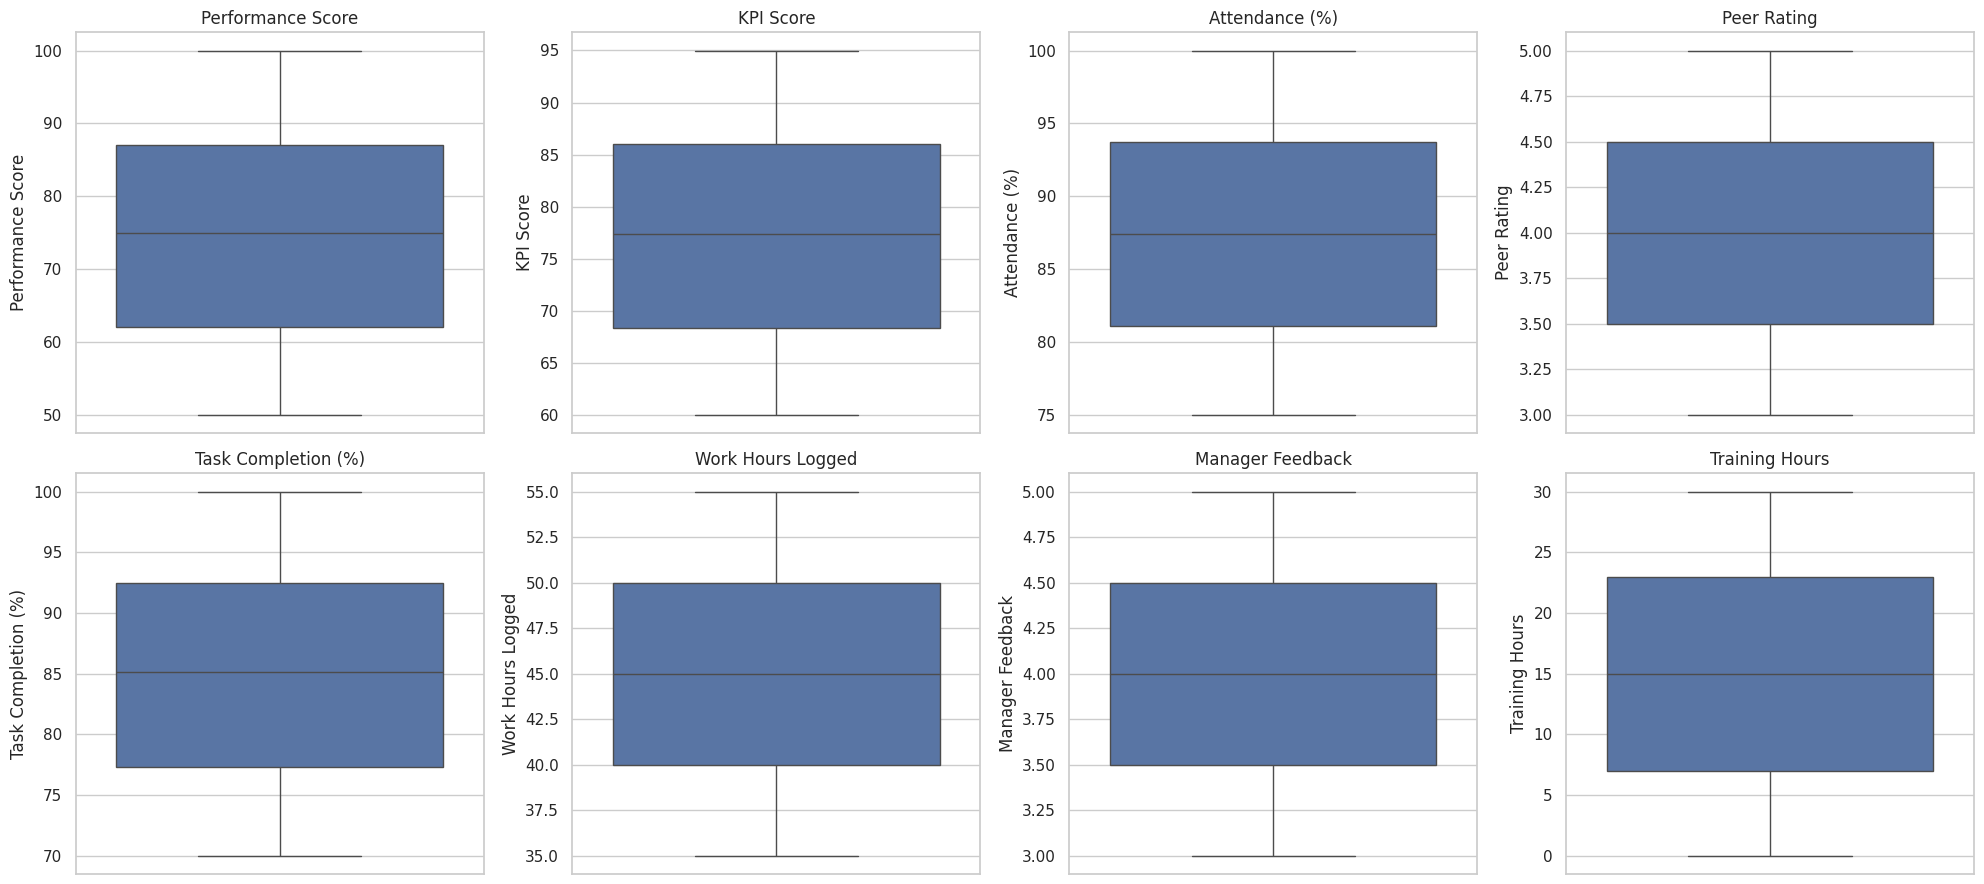

In [133]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

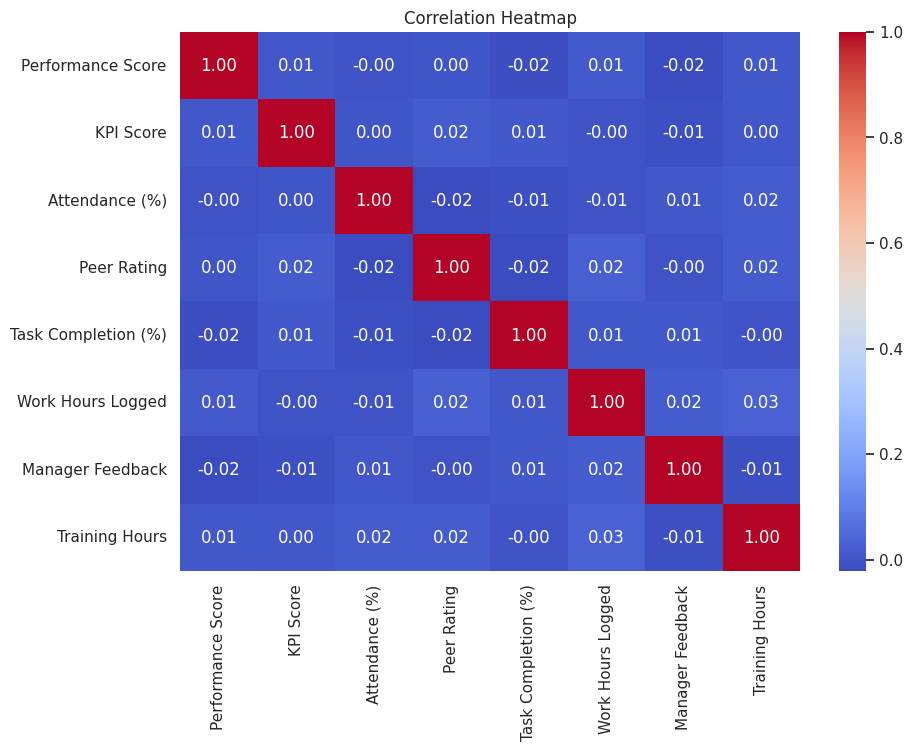

In [134]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Department
HR           15.25
Finance      14.17
Marketing    13.47
Sales        13.33
IT           13.24
Name: Promotion Eligibility, dtype: float64


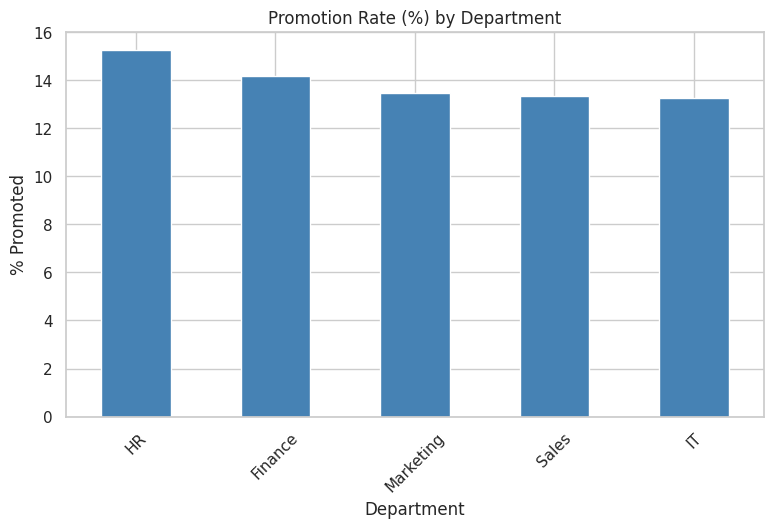

In [135]:
dept_promo = df.groupby('Department')['Promotion Eligibility'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print(dept_promo.round(2))

plt.figure(figsize=(9, 5))
dept_promo.plot(kind='bar', color='steelblue')
plt.title('Promotion Rate (%) by Department')
plt.ylabel('% Promoted')
plt.xticks(rotation=45)
plt.show()

Job Role
Accountant                  17.18
Content Strategist          16.83
Recruitment Specialist      16.42
Data Analyst                15.43
HR Manager                  15.08
Employee Relations          14.24
Business Development        14.08
Financial Analyst           13.41
Cybersecurity Specialist    13.33
Account Manager             13.12
Sales Executive             12.79
Marketing Executive         12.42
Auditor                     11.71
SEO Specialist              11.35
Software Engineer           11.01
Name: Promotion Eligibility, dtype: float64


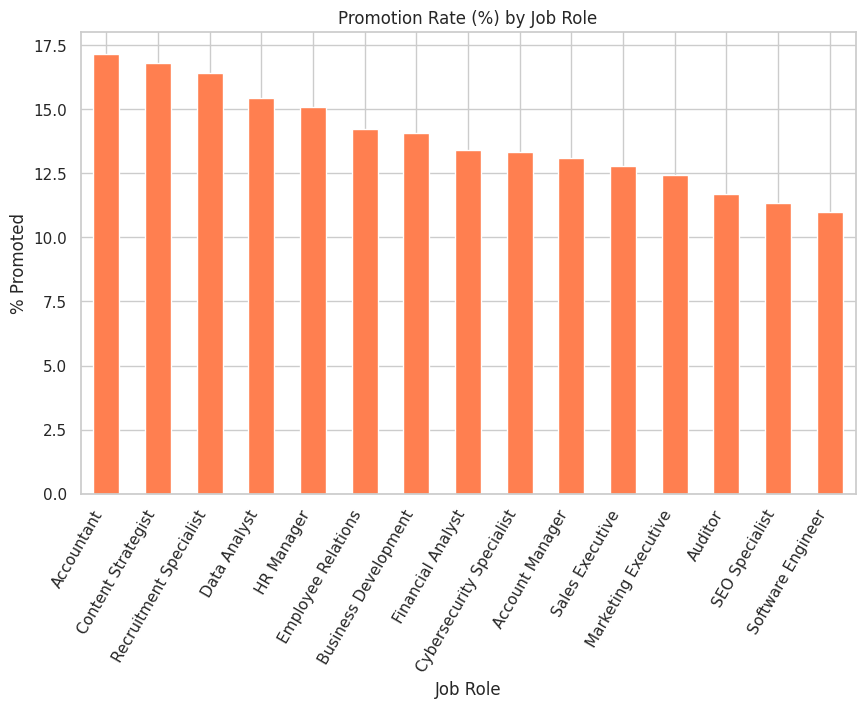

In [136]:
role_promo = df.groupby('Job Role')['Promotion Eligibility'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print(role_promo.round(2))

plt.figure(figsize=(10, 6))
role_promo.plot(kind='bar', color='coral')
plt.title('Promotion Rate (%) by Job Role')
plt.ylabel('% Promoted')
plt.xticks(rotation=60, ha='right')
plt.show()

,Performance Score,KPI Score,Attendance (%),Peer Rating,Task Completion (%),Work Hours Logged,Manager Feedback,Training Hours
Promotion Eligibility,,,,,,,,
No,71.81,77.36,87.45,4.0,85.04,44.93,3.92,14.85
Yes,93.18,77.57,87.58,4.0,84.58,44.90,4.51,15.06


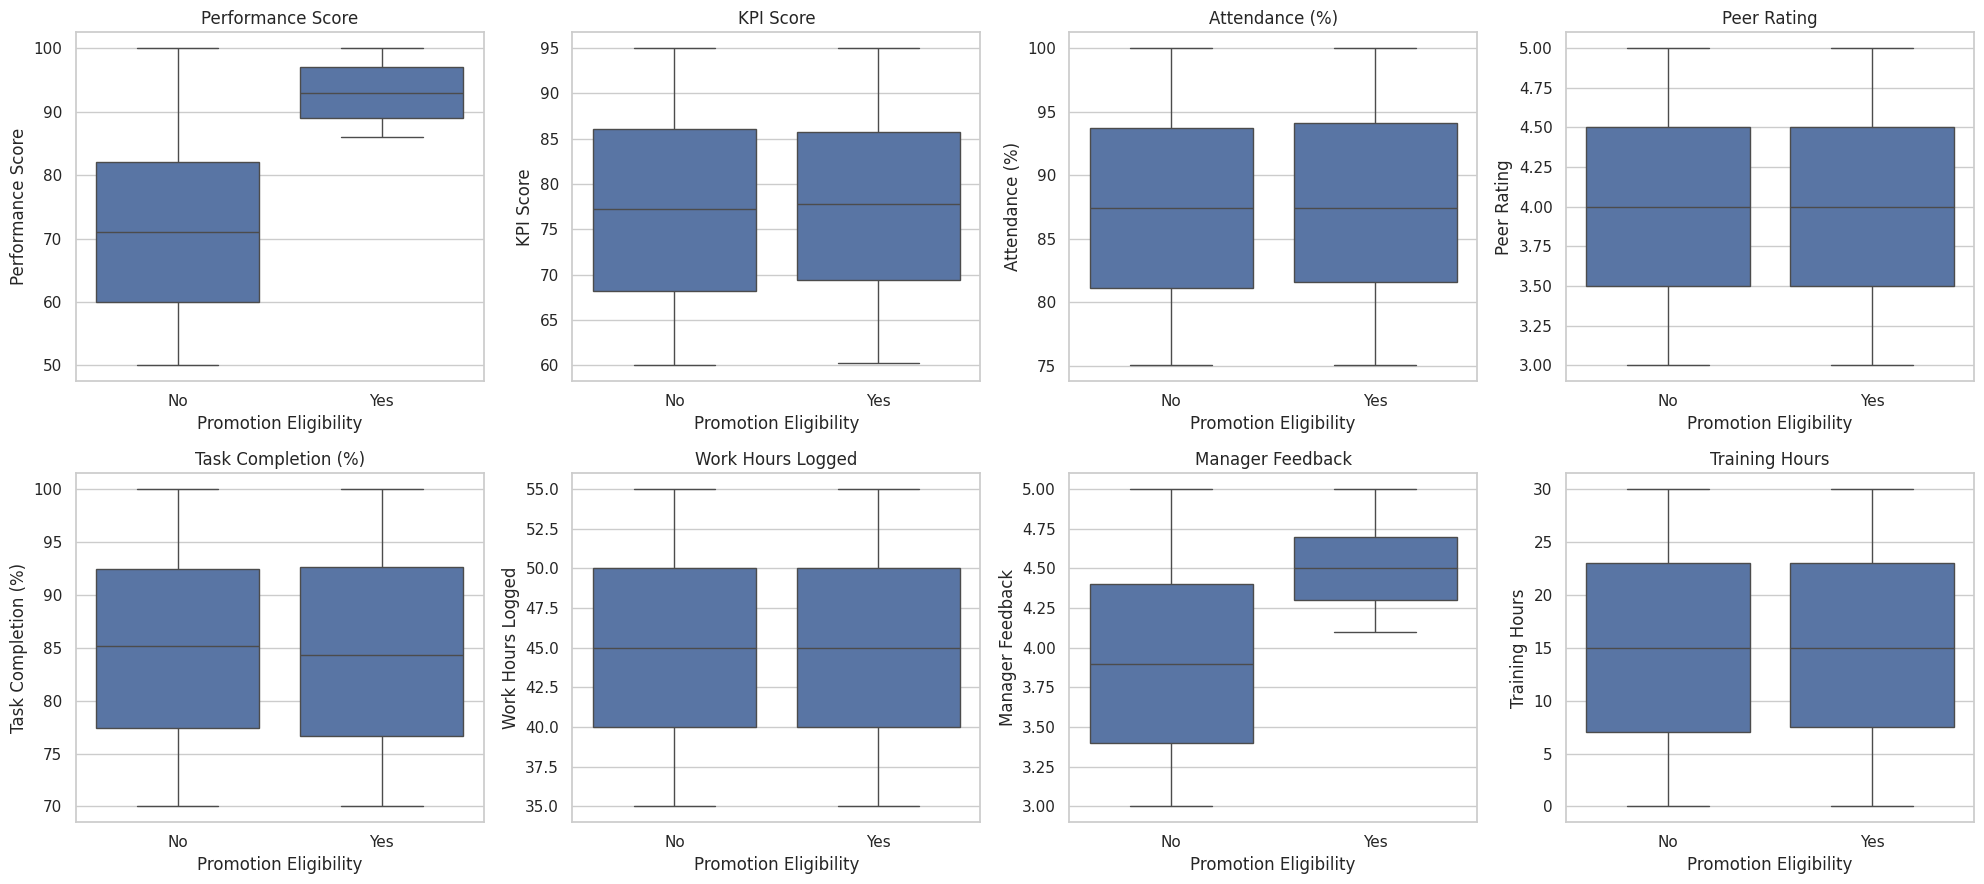

In [137]:
comparison = df.groupby('Promotion Eligibility')[numeric_cols].mean().round(2)
display(comparison)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Promotion Eligibility', y=col, data=df, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [138]:
gender_promo = df.groupby('Gender')['Promotion Eligibility'].apply(lambda x: (x == 'Yes').mean() * 100).round(2)
print(gender_promo)

Gender
Female    14.54
Male      13.26
Name: Promotion Eligibility, dtype: float64


In [139]:
df_model = df.drop(columns=['Employee ID', 'Name'])
print(df_model.columns.tolist())
print(f"Shape: {df_model.shape}")

['Gender', 'Department', 'Job Role', 'Performance Score', 'KPI Score', 'Attendance (%)', 'Peer Rating', 'Task Completion (%)', 'Work Hours Logged', 'Manager Feedback', 'Training Hours', 'Promotion Eligibility']
Shape: (5000, 12)


In [140]:
df_model['Promotion_Target'] = (df_model['Promotion Eligibility'] == 'Yes').astype(int)
df_model = df_model.drop(columns=['Promotion Eligibility'])

print(df_model['Promotion_Target'].value_counts())
print(f"\n1 = Yes (promotion eligible), 0 = No")

Promotion_Target
0    4305
1     695
Name: count, dtype: int64

1 = Yes (promotion eligible), 0 = No


In [142]:
categorical_cols = ['Gender', 'Department', 'Job Role']
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"\nColumns:\n{df_encoded.columns.tolist()}")

Shape after encoding: (5000, 28)

Columns:
['Performance Score', 'KPI Score', 'Attendance (%)', 'Peer Rating', 'Task Completion (%)', 'Work Hours Logged', 'Manager Feedback', 'Training Hours', 'Promotion_Target', 'Gender_Male', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Sales', 'Job Role_Accountant', 'Job Role_Auditor', 'Job Role_Business Development', 'Job Role_Content Strategist', 'Job Role_Cybersecurity Specialist', 'Job Role_Data Analyst', 'Job Role_Employee Relations', 'Job Role_Financial Analyst', 'Job Role_HR Manager', 'Job Role_Marketing Executive', 'Job Role_Recruitment Specialist', 'Job Role_SEO Specialist', 'Job Role_Sales Executive', 'Job Role_Software Engineer']


In [143]:
X = df_encoded.drop(columns=['Promotion_Target'])
y = df_encoded['Promotion_Target']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (5000, 27)
y shape: (5000,)


In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"\nTrain target distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Train size: 4000, Test size: 1000

Train target distribution:
Promotion_Target
0    0.861
1    0.139
Name: proportion, dtype: float64

Test target distribution:
Promotion_Target
0    0.861
1    0.139
Name: proportion, dtype: float64


In [146]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete")
print(f"Train mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Train std (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete
Train mean (should be ~0): 0.0000
Train std (should be ~1): 1.0000


In [147]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

print(f"{len(models)} models defined")

5 models defined


In [148]:
results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[model_name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")


Training Logistic Regression...
Accuracy  : 0.9570
Precision : 0.8478
Recall    : 0.8417
F1 Score  : 0.8448
ROC-AUC   : 0.9866

Training Decision Tree...
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

Training Random Forest...
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

Training KNN...
Accuracy  : 0.8880
Precision : 0.6800
Recall    : 0.3669
F1 Score  : 0.4766
ROC-AUC   : 0.9030

Training XGBoost...
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000


Performance Score      0.520563
Manager Feedback       0.349849
Attendance (%)         0.021118
Task Completion (%)    0.020851
KPI Score              0.020023
Training Hours         0.015576
Peer Rating            0.014027
Work Hours Logged      0.013658
Gender_Male            0.003161
Job Role_Accountant    0.001726
dtype: float64


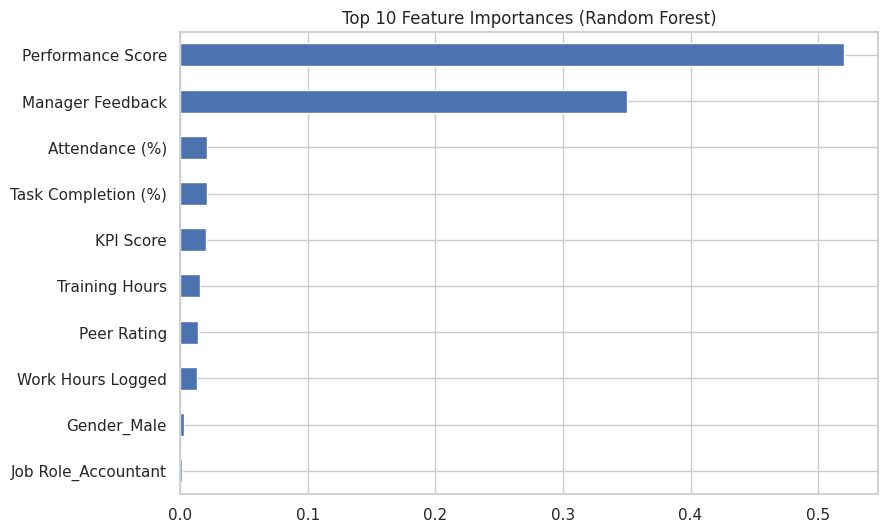

In [149]:
rf_importance = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(rf_importance.head(10))

plt.figure(figsize=(9, 6))
rf_importance.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

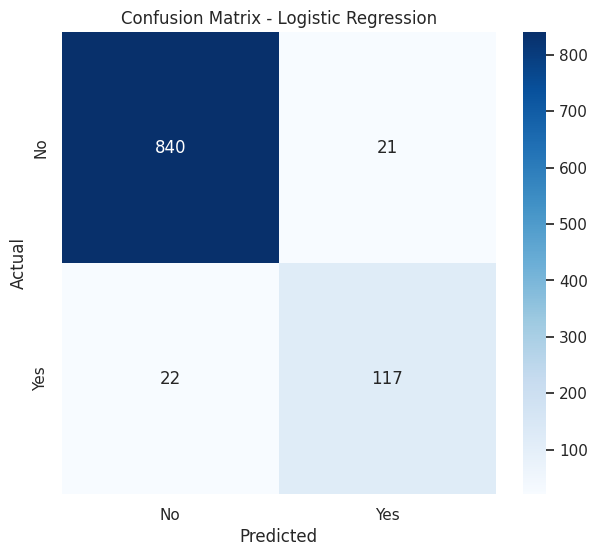

              precision    recall  f1-score   support

          No      0.974     0.976     0.975       861
         Yes      0.848     0.842     0.845       139

    accuracy                          0.957      1000
   macro avg      0.911     0.909     0.910      1000
weighted avg      0.957     0.957     0.957      1000



In [150]:
best_model_name = 'Logistic Regression'
best_pred = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(y_test, best_pred, target_names=['No', 'Yes'], digits=3))

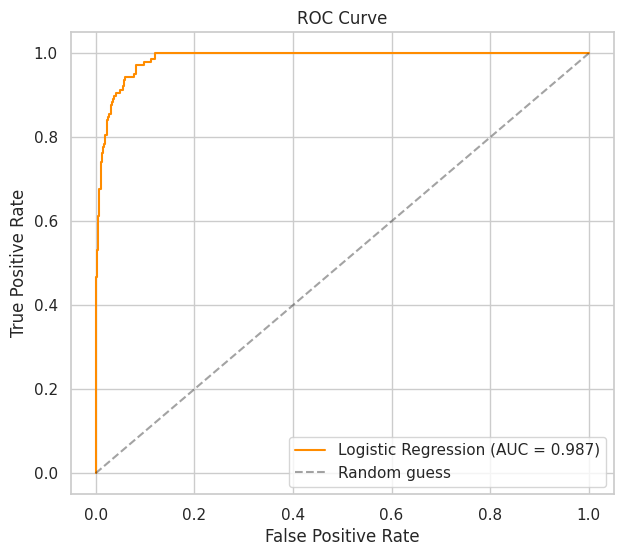

In [151]:
fpr, tpr, _ = roc_curve(y_test, results[best_model_name]['y_proba'])

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {results[best_model_name]['roc_auc']:.3f})", color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [152]:
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    X_scaled_full, y, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1'
)

print(f"F1 scores across 5 folds: {cv_scores.round(3)}")
print(f"Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

F1 scores across 5 folds: [0.87  0.865 0.835 0.827 0.798]
Mean F1: 0.8389 ± 0.0262


In [153]:
joblib.dump(results['Logistic Regression']['model'], 'promotion_eligibility_model.pkl')
joblib.dump(scaler, 'promotion_scaler.pkl')
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Model, scaler, and column list saved successfully")

Model, scaler, and column list saved successfully


In [154]:
def predict_promotion(employee_dict, model, scaler, feature_columns):
    input_df = pd.DataFrame([employee_dict])
    input_encoded = pd.get_dummies(input_df, columns=['Gender', 'Department', 'Job Role'])

    for col in feature_columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0
    input_encoded = input_encoded[feature_columns]

    input_scaled = scaler.transform(input_encoded)
    prediction = model.predict(input_scaled)[0]
    probability = model.predict_proba(input_scaled)[0][1]

    return {
        'Prediction': 'Yes' if prediction == 1 else 'No',
        'Probability': f"{probability * 100:.1f}%"
    }

# Test on a new hypothetical employee
new_employee = {
    'Gender': 'Female', 'Department': 'IT', 'Job Role': 'Software Engineer',
    'Performance Score': 95, 'KPI Score': 88, 'Attendance (%)': 92,
    'Peer Rating': 4.5, 'Task Completion (%)': 90, 'Work Hours Logged': 45,
    'Manager Feedback': 4.8, 'Training Hours': 20
}

result = predict_promotion(new_employee, results['Logistic Regression']['model'], scaler, list(X.columns))
print(result)

{'Prediction': 'Yes', 'Probability': '99.1%'}


In [155]:
test_results_df = X_test.copy()
test_results_df['Actual'] = y_test.values
test_results_df['Predicted'] = best_pred
test_results_df['Predicted_Probability'] = results['Logistic Regression']['y_proba']

test_results_df.to_csv('Promotion_Prediction_Results.csv', index=False)
print("Saved successfully")

Saved successfully


In [156]:
import ipywidgets as widgets
from IPython.display import display, clear_output

perf_slider = widgets.IntSlider(value=75, min=50, max=100, description='Performance:')
kpi_slider = widgets.FloatSlider(value=77, min=60, max=95, description='KPI Score:')
att_slider = widgets.FloatSlider(value=87, min=75, max=100, description='Attendance %:')
peer_slider = widgets.FloatSlider(value=4.0, min=3.0, max=5.0, step=0.1, description='Peer Rating:')
task_slider = widgets.FloatSlider(value=85, min=70, max=100, description='Task Compl %:')
hours_slider = widgets.IntSlider(value=45, min=35, max=55, description='Work Hours:')
feedback_slider = widgets.FloatSlider(value=4.0, min=3.0, max=5.0, step=0.1, description='Mgr Feedback:')
training_slider = widgets.IntSlider(value=15, min=0, max=30, description='Training Hrs:')

gender_dd = widgets.Dropdown(options=['Male', 'Female'], description='Gender:')
dept_dd = widgets.Dropdown(options=['HR', 'Finance', 'Marketing', 'Sales', 'IT'], description='Department:')
role_dd = widgets.Dropdown(
    options=['Accountant', 'Auditor', 'Business Development', 'Content Strategist',
             'Cybersecurity Specialist', 'Data Analyst', 'Employee Relations',
             'Financial Analyst', 'HR Manager', 'Marketing Executive',
             'Recruitment Specialist', 'SEO Specialist', 'Sales Executive',
             'Software Engineer', 'Account Manager'],
    description='Job Role:'
)

output = widgets.Output()

def on_change(change):
    with output:
        clear_output(wait=True)
        employee = {
            'Gender': gender_dd.value, 'Department': dept_dd.value, 'Job Role': role_dd.value,
            'Performance Score': perf_slider.value, 'KPI Score': kpi_slider.value,
            'Attendance (%)': att_slider.value, 'Peer Rating': peer_slider.value,
            'Task Completion (%)': task_slider.value, 'Work Hours Logged': hours_slider.value,
            'Manager Feedback': feedback_slider.value, 'Training Hours': training_slider.value
        }
        result = predict_promotion(employee, results['Logistic Regression']['model'], scaler, list(X.columns))
        color = 'green' if result['Prediction'] == 'Yes' else 'red'
        print(f"Prediction: {result['Prediction']}")
        print(f"Confidence: {result['Probability']}")

for slider in [perf_slider, kpi_slider, att_slider, peer_slider, task_slider,
               hours_slider, feedback_slider, training_slider, gender_dd, dept_dd, role_dd]:
    slider.observe(on_change, names='value')

display(widgets.VBox([
    widgets.HTML("<h3>Employee Promotion Predictor — Live</h3>"),
    gender_dd, dept_dd, role_dd,
    perf_slider, kpi_slider, att_slider, peer_slider,
    task_slider, hours_slider, feedback_slider, training_slider,
    output
]))

on_change(None)